# Diabetes Sampling and Bootstrap Analysis

This notebook analyzes `diabetes.csv`, treating the full dataset as the population.

The workflow emphasizes:

- reproducible sampling
- direct comparison between sample and population statistics
- bootstrap estimation for `BloodPressure`
- saved figures and written interpretations

The sample, summary tables, and figures are saved into the corresponding `data_clean/` and `reports/figures/` folders.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

# Keep temporary Matplotlib cache files outside the project folder.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_assignment2_q2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd()
DATA_CLEAN_DIR = (NOTEBOOK_DIR / "../data_clean").resolve()
FIGURES_DIR = (NOTEBOOK_DIR / "../reports/figures").resolve()
DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def resolve_path(*candidates: str) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find any of: {candidates}")


def save_figure(fig: plt.Figure, filename: str) -> None:
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


SEED = 42
DATA_PATH = resolve_path("../data_raw/diabetes.csv", "Assignment_2/Question2/data_raw/diabetes.csv")
population = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Population size: {len(population)}")
display(population.describe().round(2).transpose())


Dataset path: ../data_raw/diabetes.csv
Population size: 768


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## Part (a): Random sample of 25 observations and Glucose comparison

The seed is fixed to make the sample reproducible.
The sample itself is saved in `../data_clean/diabetes_sample_seed42.csv`.


In [2]:
sample_df = population.sample(n=25, random_state=SEED, replace=False).sort_index()
sample_df.to_csv(DATA_CLEAN_DIR / "diabetes_sample_seed42.csv", index=False)

glucose_comparison = pd.DataFrame(
    {
        "Sample (n=25)": [sample_df["Glucose"].mean(), sample_df["Glucose"].max()],
        "Population (N=768)": [population["Glucose"].mean(), population["Glucose"].max()],
    },
    index=["Mean Glucose", "Highest Glucose"],
)

print("Full 25-row sample used for the analysis:")
display(sample_df)
display(glucose_comparison.round(2))


Full 25-row sample used for the analysis:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
86,13,106,72,54,0,36.6,0.178,45,0
97,1,71,48,18,76,20.4,0.323,22,0
148,5,147,78,0,0,33.7,0.218,65,0
199,4,148,60,27,318,30.9,0.150,29,1
204,6,103,72,32,190,37.7,0.324,55,0
208,1,96,64,27,87,33.2,0.289,21,0
212,7,179,95,31,0,34.2,0.164,60,0
213,0,140,65,26,130,42.6,0.431,24,1
265,5,96,74,18,67,33.6,0.997,43,0
281,10,129,76,28,122,35.9,0.280,39,0


,Sample (n=25),Population (N=768)
Mean Glucose,116.64,120.89
Highest Glucose,183.00,199.00


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question2/reports/figures/q2_glucose_comparison.png


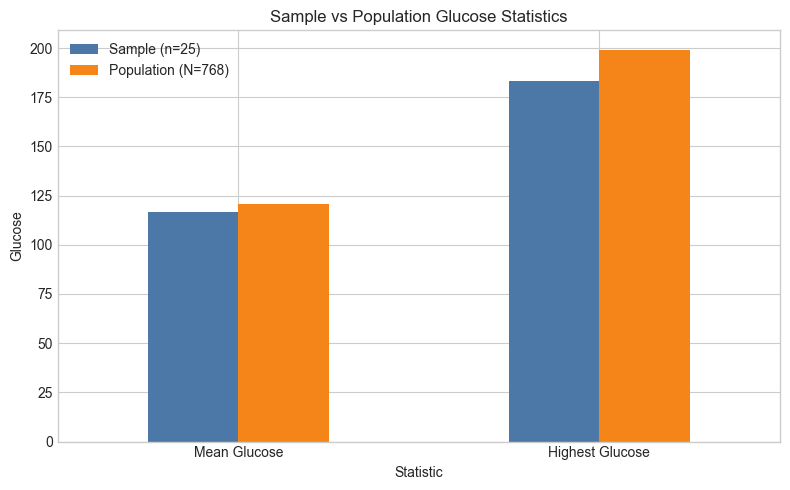

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
glucose_comparison.plot(
    kind="bar",
    ax=ax,
    color=["#4C78A8", "#F58518"],
    title="Sample vs Population Glucose Statistics",
)
ax.set_ylabel("Glucose")
ax.set_xlabel("Statistic")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
save_figure(fig, "q2_glucose_comparison.png")
plt.show()


## Part (b): 98th percentile of BMI

The sample percentile is compared with the population percentile using both a table and a chart.


,BMI 98th Percentile
Sample (n=25),40.25
Population (N=768),47.53


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question2/reports/figures/q2_bmi_percentile.png


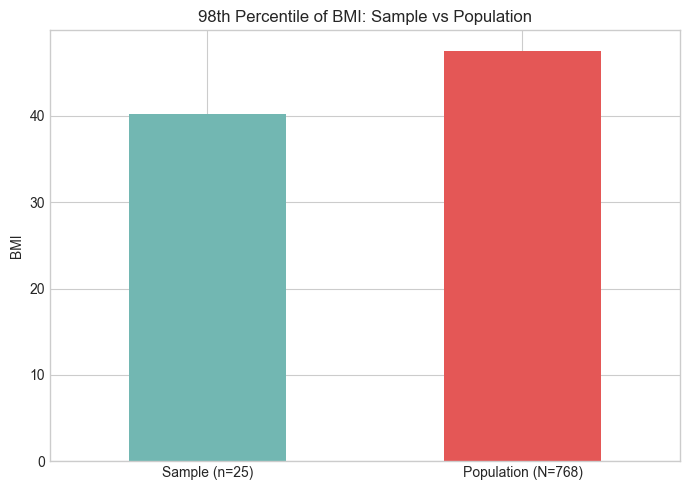

In [4]:
bmi_comparison = pd.Series(
    {
        "Sample (n=25)": np.percentile(sample_df["BMI"], 98),
        "Population (N=768)": np.percentile(population["BMI"], 98),
    },
    name="BMI 98th Percentile",
)

display(bmi_comparison.round(2).to_frame())

fig, ax = plt.subplots(figsize=(7, 5))
bmi_comparison.plot(
    kind="bar",
    ax=ax,
    color=["#72B7B2", "#E45756"],
    title="98th Percentile of BMI: Sample vs Population",
)
ax.set_ylabel("BMI")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
save_figure(fig, "q2_bmi_percentile.png")
plt.show()


## Part (c): Bootstrap analysis for BloodPressure

This section creates **500 bootstrap samples**, each with **150 observations**, from the population.

Because bootstrap sampling uses **replacement**, the same population observation can appear more than once inside a single sample. That repetition is expected and is part of the bootstrap method itself.

For each of the 500 samples, the code computes:

- the sample mean of `BloodPressure`
- the sample standard deviation of `BloodPressure`
- the sample 98th percentile of `BloodPressure`

The analysis then compares:

- the full distribution of the 500 bootstrap statistics
- the average bootstrap statistic across all 500 samples
- the corresponding statistic from the full population

There is also a useful theoretical expectation for the sample mean. By the **Central Limit Theorem**, with sample size **150**, the distribution of bootstrap means should be approximately centered at the population mean and should have a spread close to **population standard deviation / sqrt(150)**. For `BloodPressure`, that theoretical standard error is about **1.58**, and the observed bootstrap spread of the sample means is about **1.53**, which is very close.

The sample standard deviation and the 98th percentile are expected to be more variable than the mean, so their bootstrap distributions should usually look wider than the distribution of the sample means.

The full table of bootstrap sample statistics is saved in `../data_clean/`.


In [5]:
blood_pressure = population["BloodPressure"].to_numpy()
rng = np.random.default_rng(SEED)

# Create 500 bootstrap samples of size 150 using sampling with replacement.
bootstrap_indices = rng.integers(0, len(blood_pressure), size=(500, 150))
bootstrap_samples = blood_pressure[bootstrap_indices]

# Count how many distinct population observations appear in each bootstrap sample.
unique_counts = np.array([len(np.unique(row)) for row in bootstrap_indices])

# Compute the requested statistic for every bootstrap sample.
bootstrap_stats = pd.DataFrame(
    {
        "Sample_ID": np.arange(1, 501),
        "Mean": bootstrap_samples.mean(axis=1),
        "Std": bootstrap_samples.std(axis=1, ddof=0),
        "P98": np.percentile(bootstrap_samples, 98, axis=1),
        "Unique_Observations": unique_counts,
    }
).round(4)

# Compare the average bootstrap statistics with the population values.
bootstrap_summary = pd.DataFrame(
    {
        "Statistic": ["Mean", "Standard Deviation", "98th Percentile"],
        "Average_Bootstrap": [
            bootstrap_stats["Mean"].mean(),
            bootstrap_stats["Std"].mean(),
            bootstrap_stats["P98"].mean(),
        ],
        "Population": [
            blood_pressure.mean(),
            blood_pressure.std(ddof=0),
            np.percentile(blood_pressure, 98),
        ],
    }
).round(4)

bootstrap_intervals = (
    bootstrap_stats[["Mean", "Std", "P98"]]
    .quantile([0.025, 0.5, 0.975])
    .T.reset_index()
    .rename(columns={"index": "Statistic", 0.025: "P2_5", 0.5: "Median", 0.975: "P97_5"})
    .round(4)
)

# Theoretical expectation for the sample mean from the Central Limit Theorem.
population_mean = blood_pressure.mean()
population_std = blood_pressure.std(ddof=0)
theoretical_se_mean = population_std / np.sqrt(150)
observed_boot_mean_sd = bootstrap_stats["Mean"].std(ddof=0)

bootstrap_stats.to_csv(DATA_CLEAN_DIR / "bloodpressure_bootstrap_sample_stats.csv", index=False)
bootstrap_summary.to_csv(DATA_CLEAN_DIR / "bloodpressure_bootstrap_summary.csv", index=False)
bootstrap_intervals.to_csv(DATA_CLEAN_DIR / "bloodpressure_bootstrap_intervals.csv", index=False)

print(f"Average number of unique observations per bootstrap sample: {unique_counts.mean():.2f}")
print("Duplicates within a sample are expected because sampling is done with replacement.")
print(f"Theoretical standard error of the sample mean: {theoretical_se_mean:.4f}")
print(f"Observed bootstrap spread of the sample means: {observed_boot_mean_sd:.4f}")

display(bootstrap_stats.describe().round(2))
display(bootstrap_summary)
display(bootstrap_intervals)


Average number of unique observations per bootstrap sample: 136.53
Duplicates within a sample are expected because sampling is done with replacement.
Theoretical standard error of the sample mean: 1.5794
Observed bootstrap spread of the sample means: 1.5285


,Sample_ID,Mean,Std,P98,Unique_Observations
count,500.00,500.00,500.00,500.00,500.00
mean,250.50,69.14,18.98,97.89,136.53
std,144.48,1.53,2.17,4.93,3.30
min,1.00,63.85,11.84,88.08,125.00
25%,125.75,68.12,17.65,94.04,134.00
50%,250.50,69.24,19.00,96.18,137.00
75%,375.25,70.24,20.44,100.16,139.00
max,500.00,73.07,25.73,110.08,145.00


,Statistic,Average_Bootstrap,Population
0,Mean,69.1359,69.1055
1,Standard Deviation,18.9835,19.3432
2,98th Percentile,97.8882,99.3200


,Statistic,P2_5,Median,P97_5
0,Mean,66.0032,69.2366,71.8067
1,Std,14.6380,18.9973,22.8574
2,P98,90.0400,96.1800,108.0000


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question2/reports/figures/q2_bootstrap_analysis.png


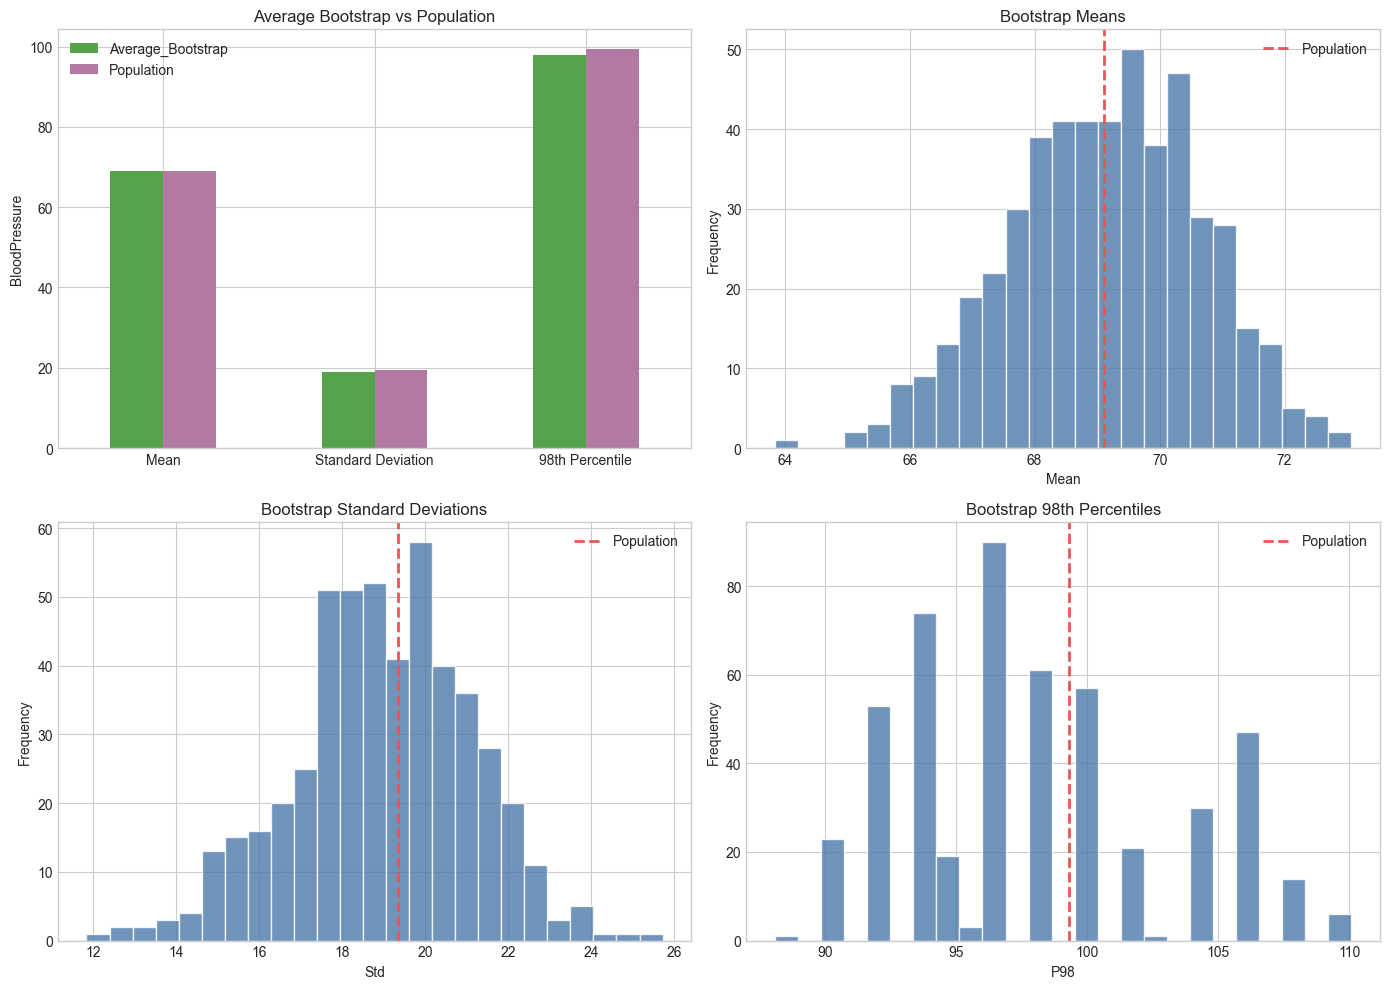

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bootstrap_plot = bootstrap_summary.set_index("Statistic")[["Average_Bootstrap", "Population"]]
bootstrap_plot.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#54A24B", "#B279A2"],
    title="Average Bootstrap vs Population",
)
axes[0, 0].set_ylabel("BloodPressure")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=0)

plot_specs = [
    ("Mean", blood_pressure.mean(), axes[0, 1], "Bootstrap Means"),
    ("Std", blood_pressure.std(ddof=0), axes[1, 0], "Bootstrap Standard Deviations"),
    ("P98", np.percentile(blood_pressure, 98), axes[1, 1], "Bootstrap 98th Percentiles"),
]

for column, population_value, axis, title in plot_specs:
    axis.hist(bootstrap_stats[column], bins=25, color="#4C78A8", alpha=0.8, edgecolor="white")
    axis.axvline(population_value, color="#E45756", linestyle="--", linewidth=2, label="Population")
    axis.set_title(title)
    axis.set_xlabel(column)
    axis.set_ylabel("Frequency")
    axis.legend()

plt.tight_layout()
save_figure(fig, "q2_bootstrap_analysis.png")
plt.show()


In [7]:
print(
    f"Part (a): Sample mean Glucose = {glucose_comparison.loc['Mean Glucose', 'Sample (n=25)']:.2f}, "
    f"while population mean Glucose = {glucose_comparison.loc['Mean Glucose', 'Population (N=768)']:.2f}."
)
print(
    f"Part (a): Sample highest Glucose = {glucose_comparison.loc['Highest Glucose', 'Sample (n=25)']:.0f}, "
    f"while population highest Glucose = {glucose_comparison.loc['Highest Glucose', 'Population (N=768)']:.0f}."
)
print(
    f"Part (b): Sample BMI 98th percentile = {bmi_comparison['Sample (n=25)']:.2f}, "
    f"while population BMI 98th percentile = {bmi_comparison['Population (N=768)']:.2f}."
)
print(
    f"Part (c): Average bootstrap mean = {bootstrap_summary.loc[0, 'Average_Bootstrap']:.2f} "
    f"vs population mean = {bootstrap_summary.loc[0, 'Population']:.2f}."
)
print(
    f"Part (c): Average bootstrap standard deviation = {bootstrap_summary.loc[1, 'Average_Bootstrap']:.2f} "
    f"vs population standard deviation = {bootstrap_summary.loc[1, 'Population']:.2f}."
)
print(
    f"Part (c): Average bootstrap 98th percentile = {bootstrap_summary.loc[2, 'Average_Bootstrap']:.2f} "
    f"vs population 98th percentile = {bootstrap_summary.loc[2, 'Population']:.2f}."
)
print(
    f"CLT check: theoretical SE of the sample mean = {theoretical_se_mean:.2f}, "
    f"observed bootstrap spread of sample means = {observed_boot_mean_sd:.2f}."
)


Part (a): Sample mean Glucose = 116.64, while population mean Glucose = 120.89.
Part (a): Sample highest Glucose = 183, while population highest Glucose = 199.
Part (b): Sample BMI 98th percentile = 40.25, while population BMI 98th percentile = 47.53.
Part (c): Average bootstrap mean = 69.14 vs population mean = 69.11.
Part (c): Average bootstrap standard deviation = 18.98 vs population standard deviation = 19.34.
Part (c): Average bootstrap 98th percentile = 97.89 vs population 98th percentile = 99.32.
CLT check: theoretical SE of the sample mean = 1.58, observed bootstrap spread of sample means = 1.53.


## Central Limit Theorem comparison for the sample mean

The figure below focuses on the distribution of the **500 bootstrap sample means** for `BloodPressure`.

- The **left panel** compares the bootstrap mean distribution with the normal shape suggested by the Central Limit Theorem.
- The **right panel** compares the theoretical standard error of the sample mean with the observed bootstrap spread of the 500 sample means.

If the sample means behave as expected, the bootstrap mean distribution should look approximately bell-shaped around the population mean, and the observed bootstrap spread should be close to the theoretical standard error.


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question2/reports/figures/q2_clt_mean_comparison.png


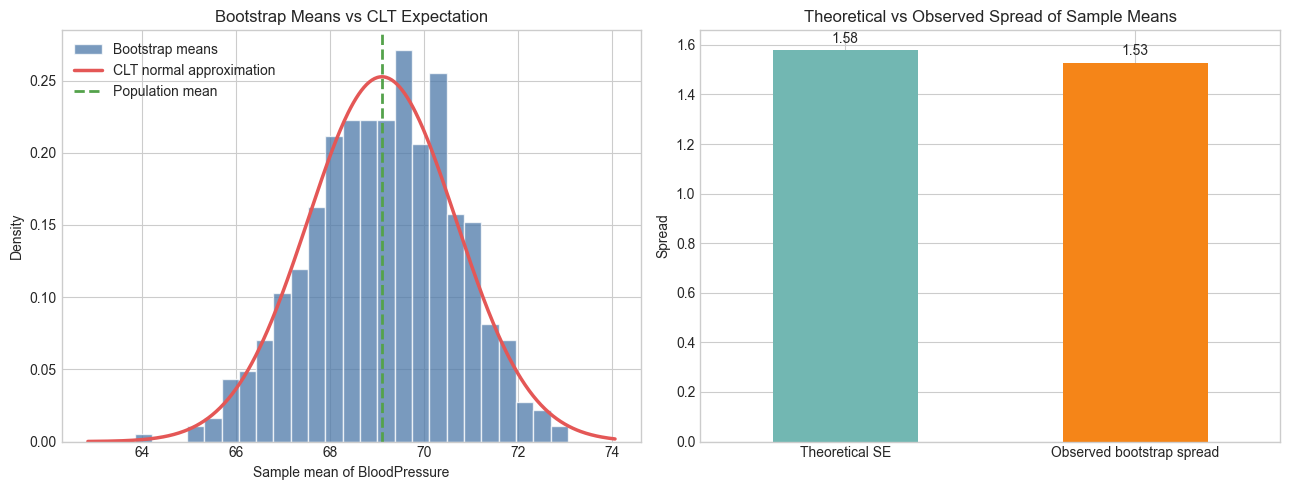

In [8]:
# Visualize the Central Limit Theorem expectation for the sample mean.
x_grid = np.linspace(
    bootstrap_stats["Mean"].min() - 1,
    bootstrap_stats["Mean"].max() + 1,
    400,
)
normal_pdf = (
    1
    / (theoretical_se_mean * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x_grid - population_mean) / theoretical_se_mean) ** 2)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    bootstrap_stats["Mean"],
    bins=25,
    density=True,
    color="#4C78A8",
    alpha=0.75,
    edgecolor="white",
    label="Bootstrap means",
)
axes[0].plot(
    x_grid,
    normal_pdf,
    color="#E45756",
    linewidth=2.5,
    label="CLT normal approximation",
)
axes[0].axvline(population_mean, color="#54A24B", linestyle="--", linewidth=2, label="Population mean")
axes[0].set_title("Bootstrap Means vs CLT Expectation")
axes[0].set_xlabel("Sample mean of BloodPressure")
axes[0].set_ylabel("Density")
axes[0].legend()

se_comparison = pd.Series(
    {
        "Theoretical SE": theoretical_se_mean,
        "Observed bootstrap spread": observed_boot_mean_sd,
    }
)
se_comparison.plot(
    kind="bar",
    ax=axes[1],
    color=["#72B7B2", "#F58518"],
    title="Theoretical vs Observed Spread of Sample Means",
)
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

for i, value in enumerate(se_comparison):
    axes[1].text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()
save_figure(fig, "q2_clt_mean_comparison.png")
plt.show()


## Final interpretation

- The random sample gives a reasonable estimate of the population mean, but it does not capture the highest population Glucose value.
- The sample BMI 98th percentile is notably lower than the population value, which shows how unstable tail estimates can be in small samples.
- The bootstrap averages are close to the true population statistics, and the bootstrap histograms show that the population values sit well inside the main range of the resampled statistics.
